In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
device

device(type='cpu')

In [5]:
ticker = 'AAPL'

In [6]:
df = yf.download(ticker, '2020-01-01')

In [7]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.271538,72.331694,71.029915,71.282568,135480400
2020-01-03,71.568924,72.326889,71.345145,71.501549,146322800
2020-01-06,72.139191,72.177691,70.442792,70.693043,118387200
2020-01-07,71.799911,72.403874,71.580942,72.148812,108872000
2020-01-08,72.954903,73.255683,71.503938,71.503938,132079200
...,...,...,...,...,...
2026-08-05,310.732025,311.441405,305.406631,309.093424,49438800
2026-08-06,312.140808,316.017470,308.963556,314.069138,46139900


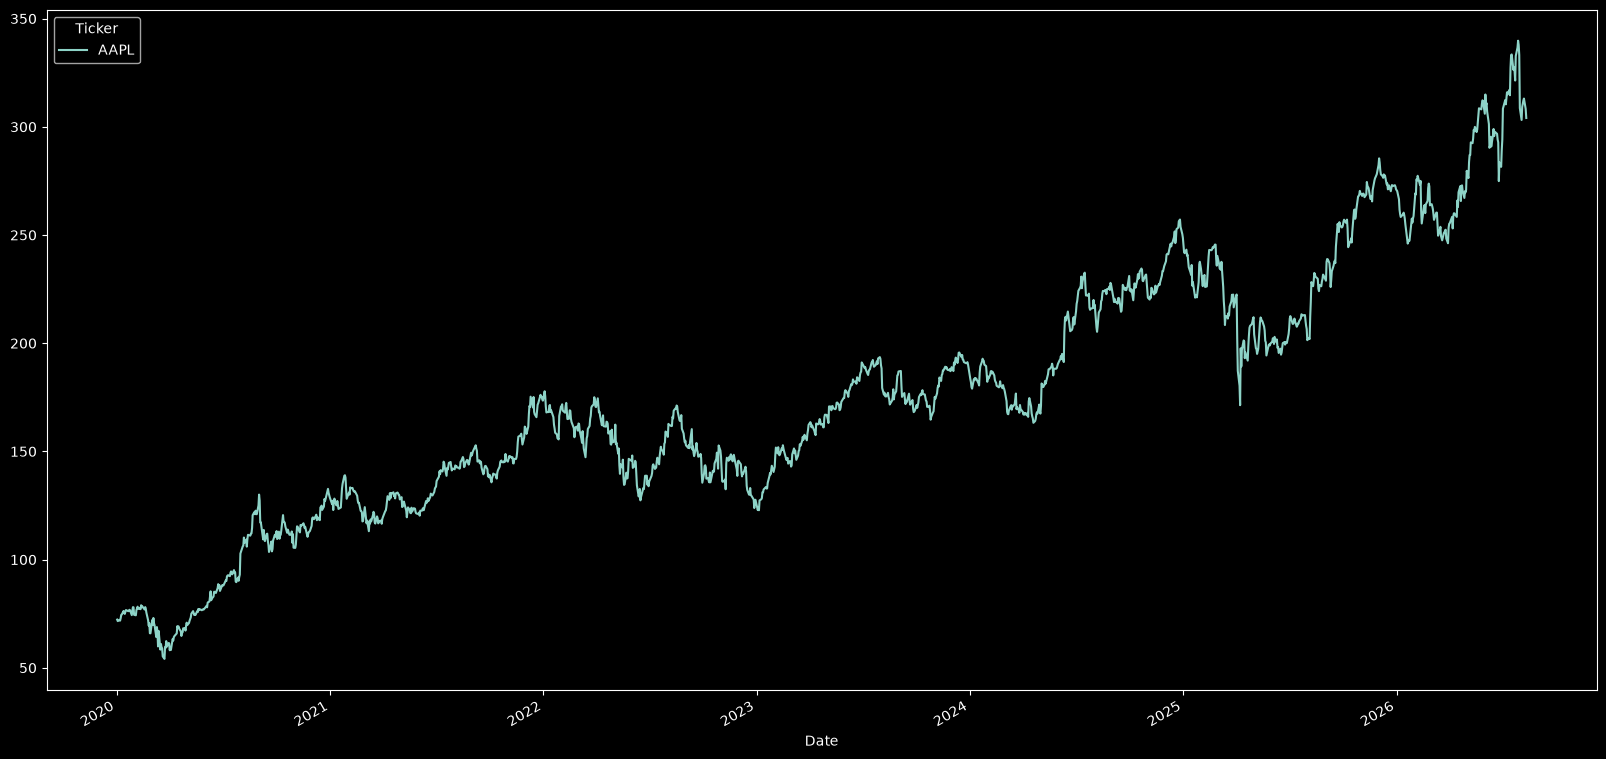

In [8]:
df.Close.plot(figsize=(20,10))

In [11]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df['Close'])

In [12]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.757370
2020-01-03,-1.769364
2020-01-06,-1.759629
2020-01-07,-1.765421
2020-01-08,-1.745704
...,...
2026-08-05,2.313490
2026-08-06,2.337540
2026-08-07,2.353232


In [20]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data = np.array(data)

In [21]:
data

array([[[-1.75736956],
        [-1.76936418],
        [-1.75962891],
        ...,
        [-1.67513767],
        [-1.64388509],
        [-1.65347916]],

       [[-1.76936418],
        [-1.75962891],
        [-1.76542089],
        ...,
        [-1.64388509],
        [-1.65347916],
        [-1.65314952]],

       [[-1.75962891],
        [-1.76542089],
        [-1.74570355],
        ...,
        [-1.65347916],
        [-1.65314952],
        [-1.67764918]],

       ...,

       [[ 1.70200657],
        [ 1.84920591],
        [ 1.81441028],
        ...,
        [ 2.28585773],
        [ 2.3134899 ],
        [ 2.33753983]],

       [[ 1.84920591],
        [ 1.81441028],
        [ 1.94438241],
        ...,
        [ 2.3134899 ],
        [ 2.33753983],
        [ 2.3532317 ]],

       [[ 1.81441028],
        [ 1.94438241],
        [ 2.0300073 ],
        ...,
        [ 2.33753983],
        [ 2.3532317 ],
        [ 2.27128909]]], shape=(1630, 30, 1))

In [22]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [23]:
class PredictionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

In [24]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [25]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [27]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)

    if i % 25 == 0:
        print(i, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

175 0.0024875819217413664


In [28]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())


In [29]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [30]:
train_rmse

2.913844585418701

In [31]:
test_rmse

5.16111421585083

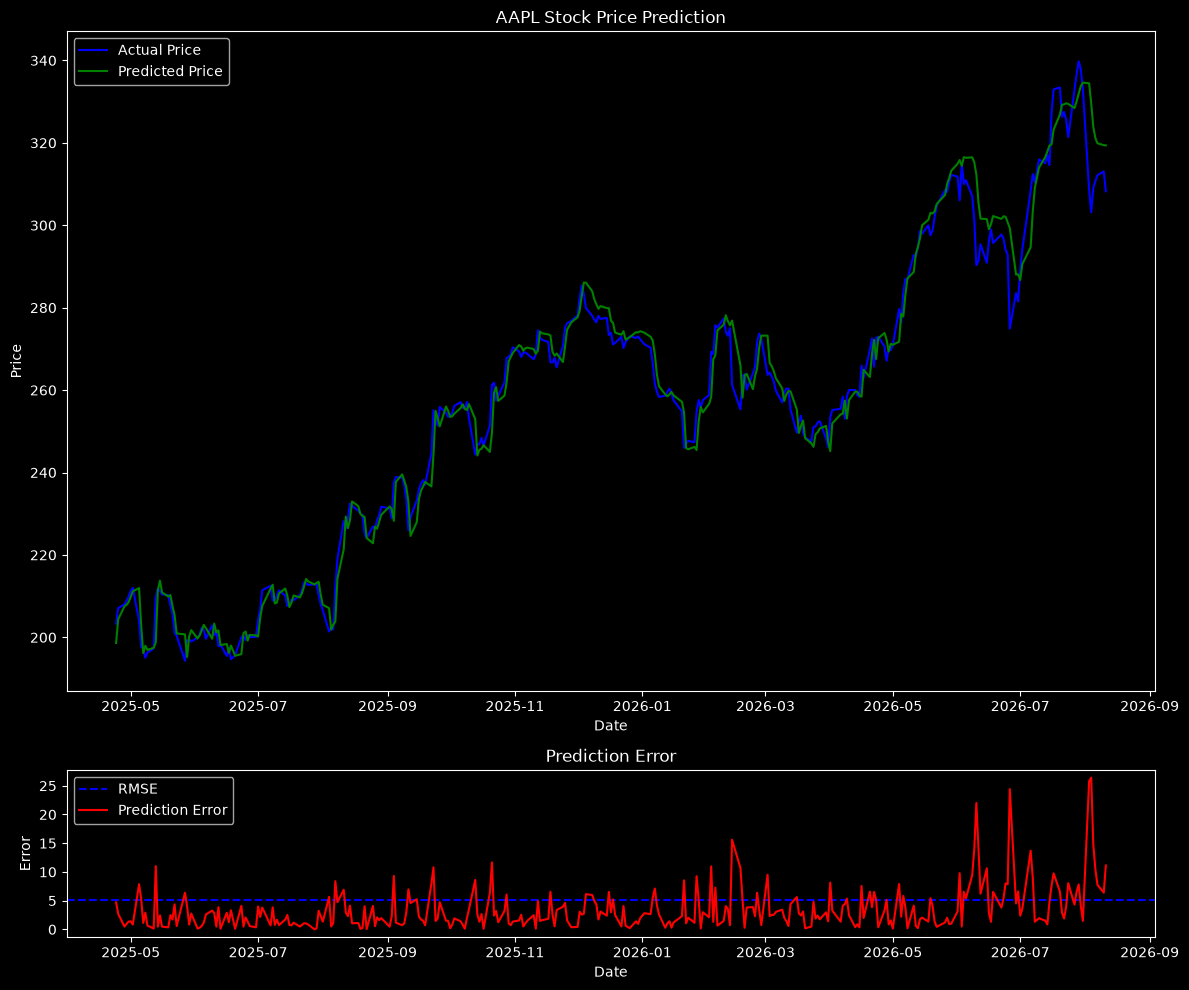

In [33]:
fig = plt.figure(figsize=(12,10))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label='Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label='Predicted Price')
ax1.legend()
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color = 'blue', linestyle = '--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label='Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()